In [2]:
import pandas as pd
import numpy as np


In [3]:
data = pd.read_csv("customers-100.csv")

data.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,DD37Cf93aecA6Dc,Sheryl,Baxter,Rasmussen Group,East Leonard,Chile,229.077.5154,397.884.0519x718,zunigavanessa@smith.info,2020-08-24,http://www.stephenson.com/
1,2,1Ef7b82A4CAAD10,Preston,Lozano,Vega-Gentry,East Jimmychester,Djibouti,5153435776,686-620-1820x944,vmata@colon.com,2021-04-23,http://www.hobbs.com/
2,3,6F94879bDAfE5a6,Roy,Berry,Murillo-Perry,Isabelborough,Antigua and Barbuda,+1-539-402-0259,(496)978-3969x58947,beckycarr@hogan.com,2020-03-25,http://www.lawrence.com/
3,4,5Cef8BFA16c5e3c,Linda,Olsen,"Dominguez, Mcmillan and Donovan",Bensonview,Dominican Republic,001-808-617-6467x12895,+1-813-324-8756,stanleyblackwell@benson.org,2020-06-02,http://www.good-lyons.com/
4,5,053d585Ab6b3159,Joanna,Bender,"Martin, Lang and Andrade",West Priscilla,Slovakia (Slovak Republic),001-234-203-0635x76146,001-199-446-3860x3486,colinalvarado@miles.net,2021-04-17,https://goodwin-ingram.com/


In [4]:
data = data.drop(columns=[
    "Index", "Customer Id", "First Name", "Last Name",
    "Company", "Phone 1", "Phone 2", "Email", "Website"
])

print("After Dropping Unnecessary Columns:")
print(data.head())

After Dropping Unnecessary Columns:
                City                     Country Subscription Date
0       East Leonard                       Chile        2020-08-24
1  East Jimmychester                    Djibouti        2021-04-23
2      Isabelborough         Antigua and Barbuda        2020-03-25
3         Bensonview          Dominican Republic        2020-06-02
4     West Priscilla  Slovakia (Slovak Republic)        2021-04-17


In [5]:
data["Subscription Date"] = pd.to_datetime(data["Subscription Date"])

# Extract useful parts
data["Year"] = data["Subscription Date"].dt.year
data["Month"] = data["Subscription Date"].dt.month

# Drop original date column
data = data.drop(columns=["Subscription Date"])

print("After Date Processing:")
print(data.head())

After Date Processing:
                City                     Country  Year  Month
0       East Leonard                       Chile  2020      8
1  East Jimmychester                    Djibouti  2021      4
2      Isabelborough         Antigua and Barbuda  2020      3
3         Bensonview          Dominican Republic  2020      6
4     West Priscilla  Slovakia (Slovak Republic)  2021      4


In [6]:
# Convert City and Country into numeric using one-hot encoding
data = pd.get_dummies(data, drop_first=True)

print("After Encoding:")
print(data.head())

After Encoding:
   Year  Month  City_Bensonview  City_Brittanyview  City_Bryanville  \
0  2020      8            False              False            False   
1  2021      4            False              False            False   
2  2020      3            False              False            False   
3  2020      6             True              False            False   
4  2021      4            False              False            False   

   City_Burchbury  City_Cassidychester  City_Chavezborough  City_Colinhaven  \
0           False                False               False            False   
1           False                False               False            False   
2           False                False               False            False   
3           False                False               False            False   
4           False                False               False            False   

   City_Coreybury  ...  Country_Togo  Country_United Arab Emirates  \
0           

In [7]:
# Create artificial target (recent vs old customers)
data["Target"] = (data["Year"] > data["Year"].median()).astype(int)

X = data.drop("Target", axis=1)
y = data["Target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Year  Month  City_Bensonview  City_Brittanyview  City_Bryanville  \
0  2020      8            False              False            False   
1  2021      4            False              False            False   
2  2020      3            False              False            False   
3  2020      6             True              False            False   
4  2021      4            False              False            False   

   City_Burchbury  City_Cassidychester  City_Chavezborough  City_Colinhaven  \
0           False                False               False            False   
1           False                False               False            False   
2           False                False               False            False   
3           False                False               False            False   
4           False                False               False            False   

   City_Coreybury  ...  Country_Togo  Country_United Arab Emirates  \
0           False 

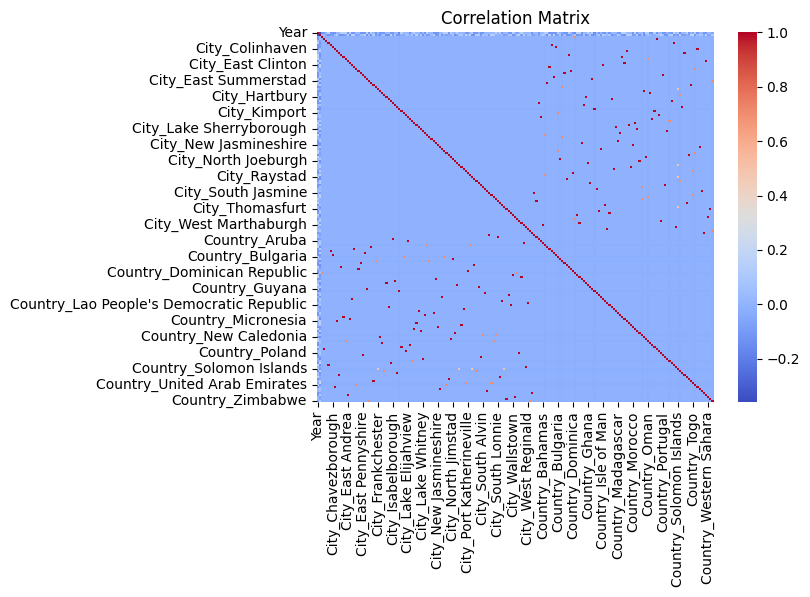

Selected Features after Correlation:
Index(['Year', 'Month', 'City_Bensonview', 'City_Brittanyview',
       'City_Bryanville', 'City_Burchbury', 'City_Cassidychester',
       'City_Chavezborough', 'City_Colinhaven', 'City_Coreybury',
       ...
       'Country_Canada', 'Country_Dominican Republic', 'Country_Netherlands',
       'Country_Oman', 'Country_Saint Vincent and the Grenadines',
       'Country_Solomon Islands',
       'Country_South Georgia and the South Sandwich Islands', 'Country_Togo',
       'Country_United Arab Emirates', 'Country_Zimbabwe'],
      dtype='object', length=113)


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X.corr()

sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Remove highly correlated features
threshold = 0.9
to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            to_drop.append(corr_matrix.columns[i])

X_corr = X.drop(columns=to_drop)

print("Selected Features after Correlation:")
print(X_corr.columns)

In [9]:
!pip install seaborn

  Using cached importlib_resources-6.4.5-py3-none-any.whl (36 kB)


You should consider upgrading via the 'c:\users\saanv\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


In [12]:
!pip install scikit-learn

You should consider upgrading via the 'c:\users\saanv\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


In [14]:
from sklearn.feature_selection import SelectKBest, chi2

# Convert True/False → 1/0
X_chi = X.astype(int)

# Now make non-negative
X_chi = X_chi - X_chi.min()

selector = SelectKBest(score_func=chi2, k=2)
X_new = selector.fit_transform(X_chi, y)

print("Selected Features using Chi-Square:")
print(X.columns[selector.get_support()])

Selected Features using Chi-Square:
Index(['Year', 'Month'], dtype='object')


In [15]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

rfe = RFE(model, n_features_to_select=2)
rfe.fit(X, y)

print("Selected Features using RFE:")
print(X.columns[rfe.support_])

Selected Features using RFE:
Index(['Country_Panama', 'Country_Singapore'], dtype='object')


In [16]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y)

importance = abs(lasso.coef_)

print("Selected Features using Lasso:")
print(X.columns[importance > 0])

Selected Features using Lasso:
Index(['Year'], dtype='object')


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

print("Feature Importance:")
for i, v in enumerate(rf.feature_importances_):
    print(f"{X.columns[i]}: {v:.4f}")

Feature Importance:
Year: 0.4281
Month: 0.0884
City_Bensonview: 0.0000
City_Brittanyview: 0.0001
City_Bryanville: 0.0001
City_Burchbury: 0.0086
City_Cassidychester: 0.0001
City_Chavezborough: 0.0001
City_Colinhaven: 0.0000
City_Coreybury: 0.0001
City_Cowanfort: 0.0001
City_Cunninghamborough: 0.0146
City_Daisyborough: 0.0143
City_Desireeshire: 0.0132
City_East Andrea: 0.0001
City_East Carly: 0.0170
City_East Clinton: 0.0000
City_East Cristinabury: 0.0000
City_East Jaredbury: 0.0033
City_East Jimmychester: 0.0002
City_East Leonard: 0.0000
City_East Pennyshire: 0.0001
City_East Rebekahborough: 0.0000
City_East Richard: 0.0106
City_East Summerstad: 0.0000
City_East Teresa: 0.0149
City_Elaineberg: 0.0001
City_Erikaville: 0.0001
City_Frankchester: 0.0005
City_Georgeport: 0.0006
City_Gwendolynview: 0.0001
City_Harmonview: 0.0000
City_Hartbury: 0.0001
City_Helenborough: 0.0010
City_Huangfort: 0.0000
City_Isabelborough: 0.0000
City_Jamesshire: 0.0000
City_Jodyberg: 0.0001
City_Judymouth: 0.0005